In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("drug200.csv")

df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nDataset Info:")
df.info()
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (200, 6)

Column Names:
Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB

Statistical Summary:
              Age     Na_to_K
count  200.000000  200.000000
mean    44.315000   16.084485
std     16.544315    7.223956
min     15.000000    6.269000
25%     31.000000   10.445500
50%     45.000000   13.936500
75%     58.000000   19.380000
max     74.000000   38.247000


In [ ]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64


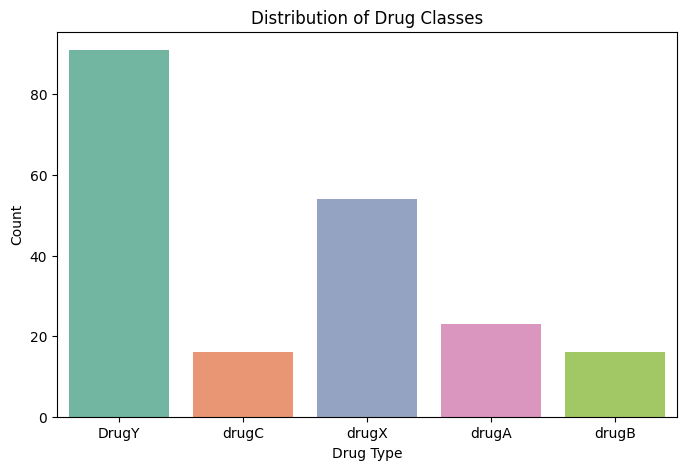

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Drug', data=df, palette='Set2')
plt.title("Distribution of Drug Classes")
plt.xlabel("Drug Type")
plt.ylabel("Count")
plt.show()

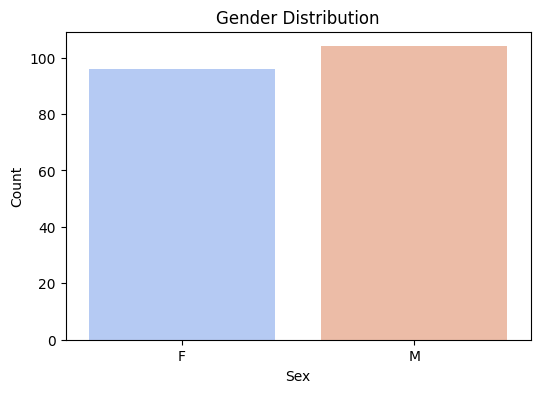

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=df, palette='coolwarm')
plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

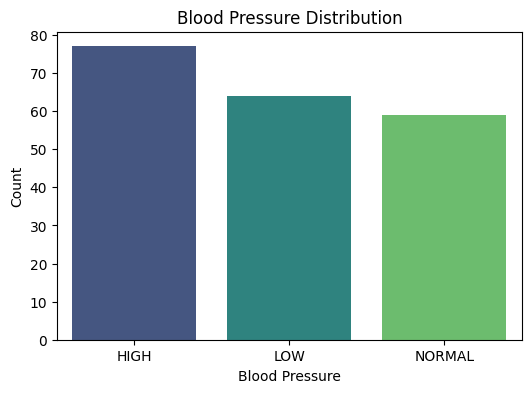

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='BP', data=df, palette='viridis')
plt.title("Blood Pressure Distribution")
plt.xlabel("Blood Pressure")
plt.ylabel("Count")
plt.show()

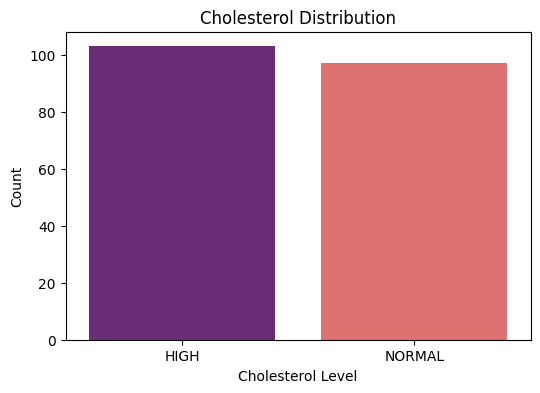

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Cholesterol', data=df, palette='magma')
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol Level")
plt.ylabel("Count")
plt.show()

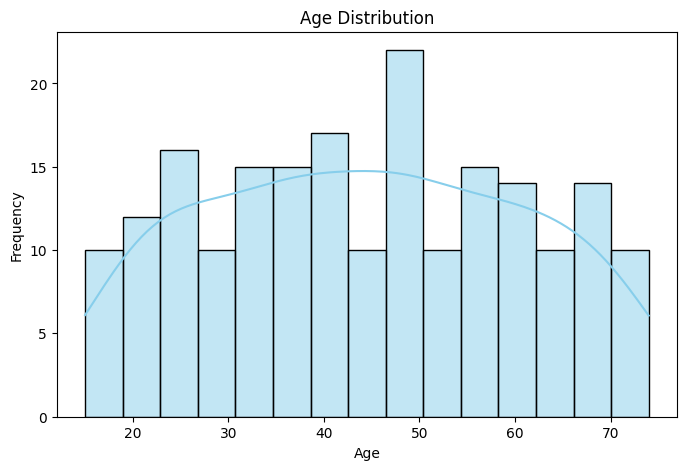

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=15, kde=True, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

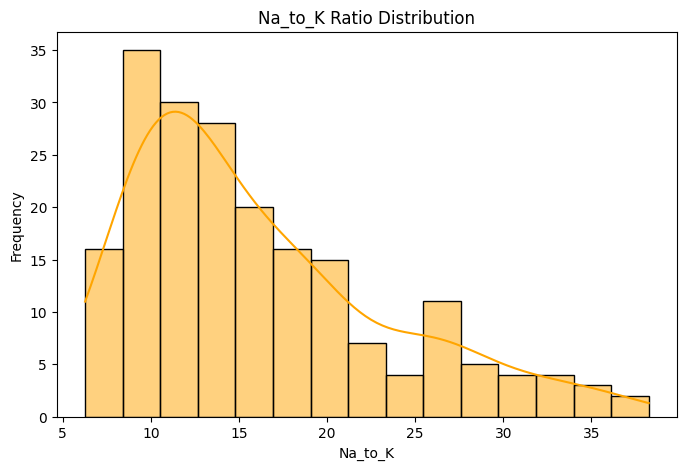

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Na_to_K'], bins=15, kde=True, color='orange')
plt.title("Na_to_K Ratio Distribution")
plt.xlabel("Na_to_K")
plt.ylabel("Frequency")
plt.show()

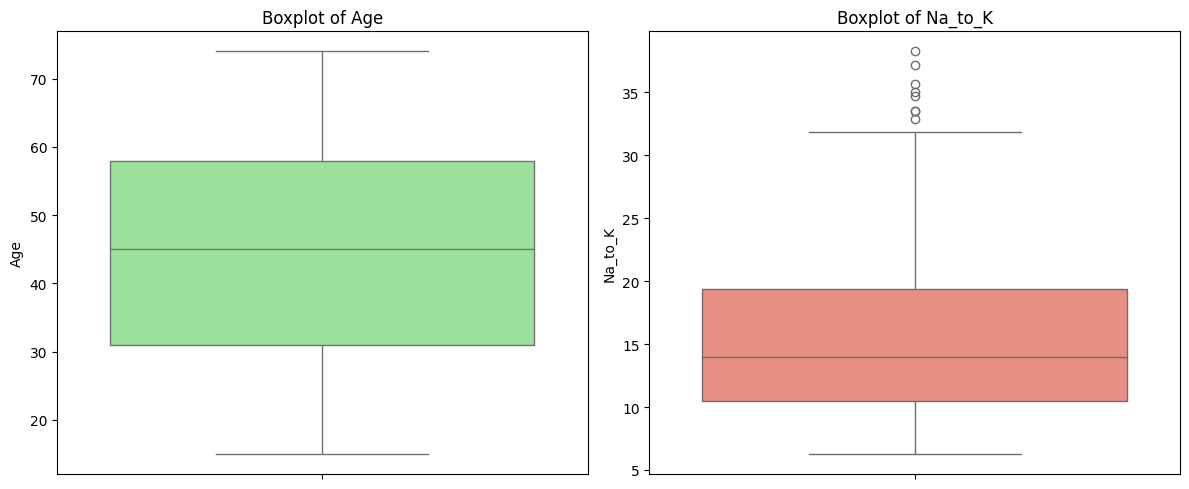

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df['Age'], color='lightgreen')
plt.title("Boxplot of Age")

plt.subplot(1,2,2)
sns.boxplot(y=df['Na_to_K'], color='salmon')
plt.title("Boxplot of Na_to_K")

plt.tight_layout()
plt.show()

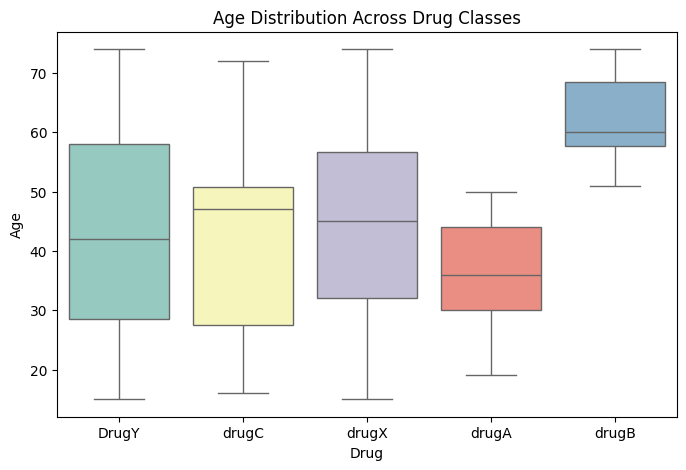

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Drug', y='Age', data=df, palette='Set3')
plt.title("Age Distribution Across Drug Classes")
plt.show()

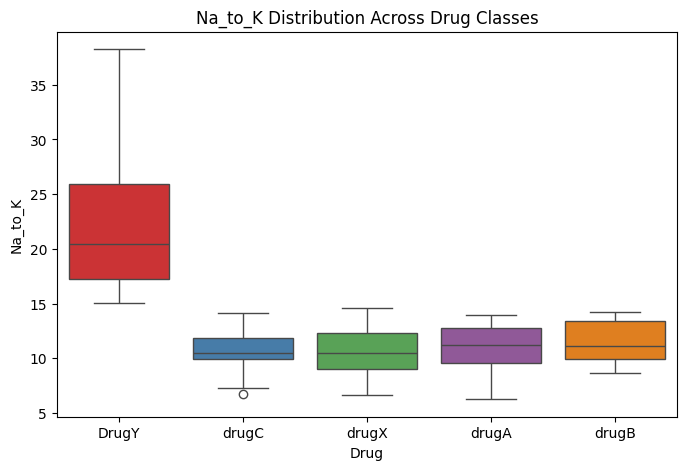

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Drug', y='Na_to_K', data=df, palette='Set1')
plt.title("Na_to_K Distribution Across Drug Classes")
plt.show()


In [ ]:
data = df.copy()
data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [ ]:
le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])
data['BP'] = le.fit_transform(data['BP'])
data['Cholesterol'] = le.fit_transform(data['Cholesterol'])
data['Drug'] = le.fit_transform(data['Drug'])
data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0


In [ ]:
X = data.drop("Drug", axis=1)

y = data["Drug"]

print("Features:\n", X.head())
print("\nTarget:\n", y.head())

Features:
    Age  Sex  BP  Cholesterol  Na_to_K
0   23    0   0            0   25.355
1   47    1   1            0   13.093
2   47    1   1            0   10.114
3   28    0   2            0    7.798
4   61    0   1            0   18.043

Target:
 0    0
1    3
2    3
3    4
4    0
Name: Drug, dtype: int64


In [ ]:
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[0, 30, 50, 100],
                         labels=['Young', 'Adult', 'Senior'])

df[['Age', 'Age_Group']].head()

,Age,Age_Group
0,23,Young
1,47,Adult
2,47,Adult
3,28,Young
4,61,Senior


In [ ]:
data['Age_Group'] = pd.cut(data['Age'],
                           bins=[0, 30, 50, 100],
                           labels=[0, 1, 2])

data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Age_Group
0,23,0,0,0,25.355,0,0
1,47,1,1,0,13.093,3,1
2,47,1,1,0,10.114,3,1
3,28,0,2,0,7.798,4,0
4,61,0,1,0,18.043,0,2


In [ ]:
X = data.drop("Drug", axis=1)
y = data["Drug"]

print("Updated Feature Columns:")
print(X.columns)

Updated Feature Columns:
Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Age_Group'], dtype='object')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (160, 6)
Testing Data Shape: (40, 6)


In [ ]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()


scale_cols = ['Age', 'Na_to_K']

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print("Scaled Training Data Sample:")
print(X_train_scaled.head())

Scaled Training Data Sample:
          Age  Sex  BP  Cholesterol   Na_to_K Age_Group
52   1.102455    1   1            1  1.573317         2
34   0.546401    1   2            0 -0.260863         2
113  1.287807    0   1            1 -0.312023         2
168  0.422833    0   1            1  0.985817         2
127 -0.565708    1   2            1 -1.144642         1


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

In [ ]:
results = []
for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, prec, rec, f1])

    print("="*50)
    print(f"Model: {name}")
    print("="*50)
    print("Accuracy:", acc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

Model: Logistic Regression
Accuracy: 0.9

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.94      0.89        18
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       0.90      0.82      0.86        11

    accuracy                           0.90        40
   macro avg       0.95      0.89      0.91        40
weighted avg       0.90      0.90      0.90        40


Confusion Matrix:

[[17  0  0  0  1]
 [ 0  5  0  0  0]
 [ 0  0  3  0  0]
 [ 1  0  0  2  0]
 [ 2  0  0  0  9]]


Model: Decision Tree
Accuracy: 0.975

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3

In [ ]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-Score"
])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
1,Decision Tree,0.975,0.976316,0.975,0.974743
2,Random Forest,0.975,0.976316,0.975,0.974743
4,SVM,0.975,0.977083,0.975,0.975186
0,Logistic Regression,0.900,0.905000,0.900,0.898346
3,KNN,0.900,0.909583,0.900,0.888175
5,Naive Bayes,0.875,0.913750,0.875,0.883009


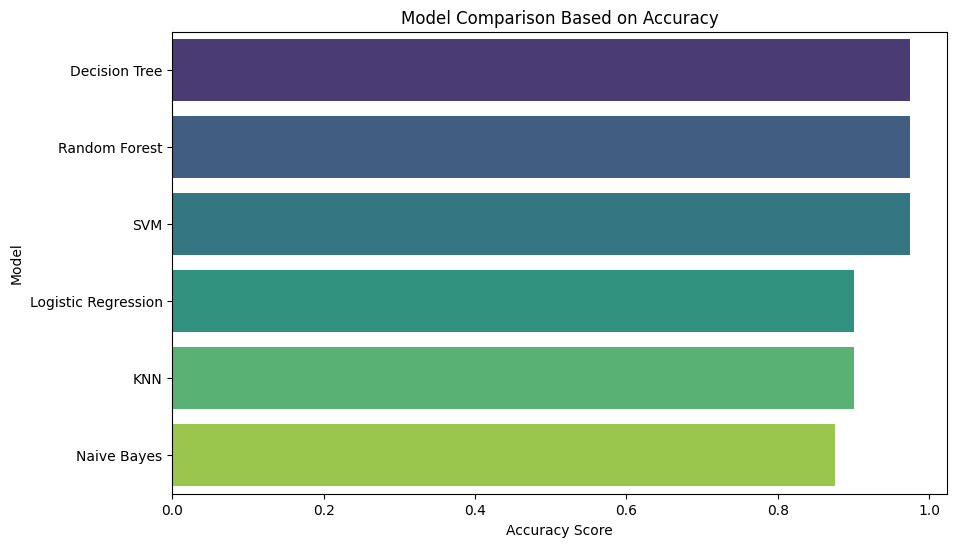

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")
plt.title("Model Comparison Based on Accuracy")
plt.xlabel("Accuracy Score")
plt.ylabel("Model")
plt.show()

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters Found:")
print(grid_search.best_params_)

best_rf = grid_search.best_estimator_

Best Parameters Found:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
y_pred_best = best_rf.predict(X_test)

best_acc = accuracy_score(y_test, y_pred_best)
best_prec = precision_score(y_test, y_pred_best, average='weighted')
best_rec = recall_score(y_test, y_pred_best, average='weighted')
best_f1 = f1_score(y_test, y_pred_best, average='weighted')

print("="*50)
print("TUNED RANDOM FOREST PERFORMANCE")
print("="*50)

print("Accuracy:", best_acc)
print("Precision:", best_prec)
print("Recall:", best_rec)
print("F1-Score:", best_f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_best))

TUNED RANDOM FOREST PERFORMANCE
Accuracy: 0.975
Precision: 0.9763157894736842
Recall: 0.975
F1-Score: 0.9747425997425998

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      0.91      0.95        11

    accuracy                           0.97        40
   macro avg       0.99      0.98      0.99        40
weighted avg       0.98      0.97      0.97        40


Confusion Matrix:

[[18  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0  3  0]
 [ 1  0  0  0 10]]


In [ ]:
print("Final Selected Model: Tuned Random Forest Classifier")
print("Reason:")
print("- High Accuracy")
print("- Better Generalization")
print("- Reduced Overfitting")
print("- Strong performance on classification task")

Final Selected Model: Tuned Random Forest Classifier
Reason:
- High Accuracy
- Better Generalization
- Reduced Overfitting
- Strong performance on classification task


In [ ]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

print(feature_importances)

       Feature  Importance
4      Na_to_K    0.524037
2           BP    0.242017
0          Age    0.124484
3  Cholesterol    0.049424
5    Age_Group    0.037855
1          Sex    0.022184


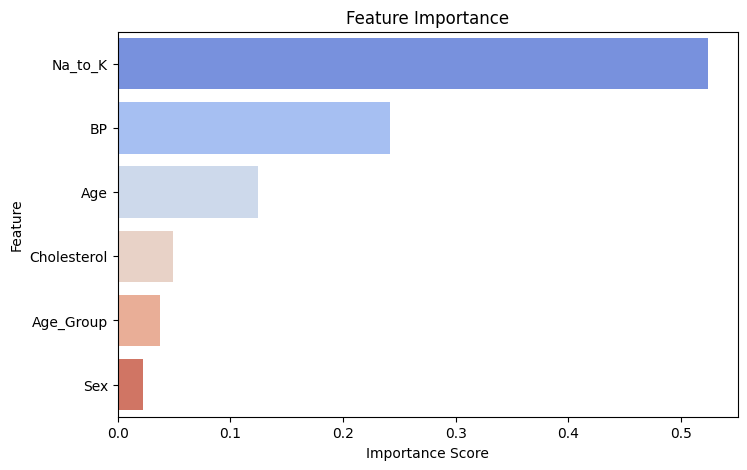

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='coolwarm')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [ ]:
new_patient = pd.DataFrame({
    'Age': [45],
    'Sex': [1],
    'BP': [0],
    'Cholesterol': [1],
    'Na_to_K': [15.2],
    'Age_Group': [1]
})


prediction = best_rf.predict(new_patient)

print("Predicted Drug Class (Encoded):", prediction[0])

Predicted Drug Class (Encoded): 0


In [ ]:
drug_encoder = LabelEncoder()
drug_encoder.fit(df['Drug'])

predicted_drug = drug_encoder.inverse_transform(prediction)

print("Predicted Drug Name:", predicted_drug[0])

Predicted Drug Name: DrugY


In [ ]:
print("""
Conclusion:
-----------
This project successfully applied multiple machine learning models
to classify drugs based on patient characteristics such as Age, Sex,
Blood Pressure, Cholesterol, and Na_to_K ratio.

After preprocessing, feature engineering, model training, evaluation,
and hyperparameter tuning, the Tuned Random Forest model was selected
as the final best-performing model.

This model can be used to predict the most suitable drug class for
new patient data.
""")


Conclusion:
-----------
This project successfully applied multiple machine learning models
to classify drugs based on patient characteristics such as Age, Sex,
Blood Pressure, Cholesterol, and Na_to_K ratio.

After preprocessing, feature engineering, model training, evaluation,
and hyperparameter tuning, the Tuned Random Forest model was selected
as the final best-performing model.

This model can be used to predict the most suitable drug class for
new patient data.

